## Exploratory Data Analysis of karnataka Agricultural dataset

## Project Objective

The goal of this project is to perform exploratory data analysis (EDA) on the Karnataka Agricultural Dataset to understand its structure, identify data quality issues, and uncover meaningful patterns and insights through statistical analysis and data visualization.

## Dataset Overview

This dataset contains agricultural information from Karnataka, India. It includes features related to crop production and other agricultural attributes that can be explored to better understand the characteristics of the data.

### Tools & Libraries

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

### Workflow

- Import libraries
- Load dataset
- Inspect data structure
- Handle missing values
- Check duplicate records
- Perform descriptive statistics
- Visualize distributions
- Explore relationships between variables
- Summarize key findings

In [1]:
#import_libraries

import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load_the_data

Data = pd.read_csv('karnataka.csv')

#convert_to_df

df = pd.DataFrame(Data)

### Dataset Information

In [3]:
#Dataset_information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3158 entries, 0 to 3157
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Year         3158 non-null   int64  
 1   Location     3158 non-null   object 
 2   Area         3155 non-null   object 
 3   Rainfall     3157 non-null   object 
 4   Temperature  3157 non-null   object 
 5   Soil type    3100 non-null   object 
 6   Irrigation   3156 non-null   object 
 7   yeilds       3158 non-null   object 
 8   Humidity     3156 non-null   float64
 9   Crops        3156 non-null   object 
 10  price        3157 non-null   float64
 11  Season       3157 non-null   object 
dtypes: float64(2), int64(1), object(9)
memory usage: 296.2+ KB


In [4]:
#number_of_rows&columns

rows, columns =df.shape
print(f"Number of Rows are : {rows}",'\n',f"Number of columns are : {columns}")

Number of Rows are : 3158 
 Number of columns are : 12


In [5]:
df.head(5)

,Year,Location,Area,Rainfall,Temperature,Soil type,Irrigation,yeilds,Humidity,Crops,price,Season
0,2004,Mangalore,1279,2903.1,27,Alluvial,Drip,2570,57.0,Coconut,200000.0,Kharif
1,2004,Mangalore,13283,2903.1,27,Alluvial,Drip,27170,57.5,Coconut,4847.0,Kharif
2,2004,Mangalore,52119,2903.1,27,Alluvial,Drip,114744,57.0,Coconut,51239.0,Kharif
3,2004,Mangalore,725,2996.6,27,Alluvial,Drip,1402,55.0,Coconut,216396.0,Kharif
4,2004,Mangalore,12885,2996.6,27,Alluvial,Drip,23456,56.0,Coconut,2644.0,Kharif


In [6]:
df.describe(include='all')

,Year,Location,Area,Rainfall,Temperature,Soil type,Irrigation,yeilds,Humidity,Crops,price,Season
count,3158.000000,3158,3155,3157,3157,3100,3156,3158,3156.000000,3156,3157.000000,3157
unique,NaN,11,157,23,107,27,3,163,NaN,13,NaN,3
top,NaN,Hassan,4,2903.1,27,Alluvial,Drip,187,NaN,Coconut,NaN,Rabi
freq,NaN,798,54,306,672,459,1310,60,NaN,1456,NaN,1742
mean,2009.929702,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55.581274,NaN,86532.987646,NaN
std,5.100895,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.470190,NaN,94892.570873,NaN
min,2004.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.000000,NaN,637.000000,NaN
25%,2004.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,54.000000,NaN,2644.000000,NaN
50%,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56.000000,NaN,45186.000000,NaN
75%,2015.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,57.000000,NaN,203317.000000,NaN


In [7]:
#Column_Details

def col_detail (df):
    col_name = []
    dtypes = []
    count = []
    unique = []
    for col in df.columns:
        col_name.append(col)
        dtypes.append(df[col].dtype)
        count.append(len(df[col]))
        unique.append(len(df[col].unique()))
        
    output = pd.DataFrame({
        'Column_name' : col_name,
        'Dtype' : dtypes,
        'Count' : count,
        'Unique': unique
    })
    return output

col_detail(df)

,Column_name,Dtype,Count,Unique
0,Year,int64,3158,16
1,Location,object,3158,11
2,Area,object,3158,158
3,Rainfall,object,3158,24
4,Temperature,object,3158,108
5,Soil type,object,3158,28
6,Irrigation,object,3158,4
7,yeilds,object,3158,163
8,Humidity,float64,3158,20
9,Crops,object,3158,14


## Data Cleaning


### Missing Values

In [8]:
#missing_values_each_col

print("Number of missing values in each column :" , "\n ")
print(df.isna().sum())

#number_of_missing_values
num_of_missing_value= df.isna().sum().sum()

print(f"number of missing values : {num_of_missing_value}")

Number of missing values in each column : 
 
Year            0
Location        0
Area            3
Rainfall        1
Temperature     1
Soil type      58
Irrigation      2
yeilds          0
Humidity        2
Crops           2
price           1
Season          1
dtype: int64
number of missing values : 71


In [9]:
#Unique_Values

for column in df.columns:
    print(f"Unique Values in '{column}':")
    print(df[column].unique())
    print("_"*40)

Unique Values in 'Year':
[2004 2013 2014 2015 2016 2017 2018 2005 2006 2007 2008 2009 2010 2011
 2012 2019]
________________________________________
Unique Values in 'Location':
['Mangalore' 'Kodagu' 'Kasaragodu' 'Raichur' 'Gulbarga' 'Madikeri'
 'Hassan' 'Mysuru' 'Chikmangaluru' 'Bangalore' 'Davangere']
________________________________________
Unique Values in 'Area':
['1279' '13283' '52119' '725' '12885' '51179' '468' '11841' '50975' '206'
 '10922' '51390' '177' '10723' '51709' '146' '10910' '51355' '160' '10912'
 '51353' '142' '10505' '51040' '154' '10318' '48083' '143' '9283' '47200'
 '158' '8982' '46990' '103' '8239' '44563' '96' '6949' '44663' '110'
 '6824' '43013' '95' '6441' '4012' '4877' '4930' '4954' '5019' '5127'
 '5174' '5294' '5474' '5864' '7028' '7403' '7501' '7714' '7856' '32' '1'
 '30' '6' '15' '4' '39' '12' '3' '17' '9' '21' '11' '8' '29' '13736'
 '14003' '14179' '14319' '14464' '14876' '14976' '15009' '15114' '16224'
 '17095' '17512' '17587' '17771' '17825' '3147' '257

In [10]:
#Replace_wrong_values
df.replace(['?','_'], np.nan, inplace=True)

#Check_missing_values_2
print("Number of missing values in each column :" , "\n ")
print(df.isna().sum())

#number_of_missing_values_after_replace
num_of_missing_value2 = df.isna().sum().sum()
print(f"number of missing values after replace : {num_of_missing_value2}")

Number of missing values in each column : 
 
Year            0
Location        0
Area            4
Rainfall        2
Temperature     2
Soil type      58
Irrigation      2
yeilds          1
Humidity        2
Crops           2
price           1
Season          1
dtype: int64
number of missing values after replace : 75


In [11]:
#percent_of_missing_values

percent_missing = (df.isnull().sum() * 100) / len(df)
percent = pd.DataFrame({'Column_name':df.columns, 'Percent_missing' : percent_missing})
print(percent)

             Column_name  Percent_missing
Year                Year         0.000000
Location        Location         0.000000
Area                Area         0.126662
Rainfall        Rainfall         0.063331
Temperature  Temperature         0.063331
Soil type      Soil type         1.836605
Irrigation    Irrigation         0.063331
yeilds            yeilds         0.031666
Humidity        Humidity         0.063331
Crops              Crops         0.063331
price              price         0.031666
Season            Season         0.031666


In [12]:
#Show_rows_with_missing_values
rows_with_missing = df[df.isna().any(axis=1)]

#Display_rows_with_missing_values
from IPython.display import display
display(rows_with_missing)

,Year,Location,Area,Rainfall,Temperature,Soil type,Irrigation,yeilds,Humidity,Crops,price,Season
59,2004,Raichur,32,3360,27.2,Red,NaN,114,56.0,Coconut,57259.0,Rabi
60,2004,Raichur,1,3360,27.2,Red,NaN,3,57.0,Coconut,234779.0,Rabi
86,2004,Gulbarga,15009,236,43,Black,Basin,73730,53.0,NaN,646.0,Zaid
114,2004,Gulbarga,2034,3550,38,Loam,Spray,3899,59.5,NaN,51239.0,Zaid
197,2004,Hassan,8239,NaN,194,Alluvial,Basin,5518,57.0,Ginger,249978.0,Kharif
...,...,...,...,...,...,...,...,...,...,...,...,...
3153,2013,Davangere,46990,3296,27,NaN,Drip,107809,53.5,Coconut,51239.0,Rabi
3154,2014,Davangere,103,3296,27,NaN,Drip,1132,52.5,Coconut,216396.0,Rabi
3155,2015,Davangere,8239,3550,27,NaN,Drip,23960,56.0,Coconut,2644.0,Rabi
3156,2016,Davangere,44563,3550,27,NaN,Drip,126487,57.0,Coconut,44235.0,Rabi


Since we have 75 missing values in 74 rows, there is no significant overlap.

In [13]:
#count_the_number_of_rows_with_missing
number_of_rows_with_missing = df.isna().any(axis=1).sum()

#total_number_of_rows
total_rows = len(df)

#percentage_of_rows_with_missing_v
percentage_missing = (number_of_rows_with_missing/ total_rows) *100

#result

print(f"Number of rows with missing values:{number_of_rows_with_missing}")
print(f"percentage of rows with missing values : {percentage_missing:0.2f} %")

Number of rows with missing values:74
percentage of rows with missing values : 2.34 %


_74 rows out of 3158 rows contain missing values(2.3%)._

There are 74 rows with missing values out of 3,158 rows. Since this represents a relatively small portion of the dataset, I decided to remove these rows rather than impute the missing values.

In [14]:
#Remove_rows_containing_missing_values
df.dropna(inplace=True)
df.shape

(3084, 12)

### Duplicate Values

In [15]:
#Number_of_Duplicate_values

num_dup = df.duplicated().sum()

if num_dup ==0 :
    print("There are no duplicated rows in this dataset.")
else:
    print(f"There are {num_dup} duplicated rows in this dataset.")

There are no duplicated rows in this dataset.


In [16]:
#Column_Detail

def col_detail (df):
    col_name = []
    dtypes = []
    count = []
    unique = []
    for col in df.columns:
        col_name.append(col)
        dtypes.append(df[col].dtype)
        count.append(len(df[col]))
        unique.append(len(df[col].unique()))
        
    output = pd.DataFrame({
        'Column_name' : col_name,
        'Dtype' : dtypes,
        'Count' : count,
        'Unique': unique
    })
    return output

col_detail(df)

,Column_name,Dtype,Count,Unique
0,Year,int64,3084,16
1,Location,object,3084,9
2,Area,object,3084,156
3,Rainfall,object,3084,22
4,Temperature,object,3084,106
5,Soil type,object,3084,27
6,Irrigation,object,3084,3
7,yeilds,object,3084,162
8,Humidity,float64,3084,19
9,Crops,object,3084,13


### Data Types

In [17]:
#Change_Data_Types_of_Numeric_Columns

#Area
df['Area'] = df['Area'].astype(int)

#Rainfall
df['Rainfall'] = df['Rainfall'].astype(float)

#Temperature
df['Temperature'] = df['Temperature'].astype(float)

#yeilds
df['yeilds'] = df['yeilds'].astype(float)

In [18]:
#verify_data_types

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3084 entries, 0 to 3099
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Year         3084 non-null   int64  
 1   Location     3084 non-null   object 
 2   Area         3084 non-null   int64  
 3   Rainfall     3084 non-null   float64
 4   Temperature  3084 non-null   float64
 5   Soil type    3084 non-null   object 
 6   Irrigation   3084 non-null   object 
 7   yeilds       3084 non-null   float64
 8   Humidity     3084 non-null   float64
 9   Crops        3084 non-null   object 
 10  price        3084 non-null   float64
 11  Season       3084 non-null   object 
dtypes: float64(5), int64(2), object(5)
memory usage: 313.2+ KB


### Value Counts for Categorical Columns

In [19]:

counts= {}

for i in df[["Location","Soil type","Irrigation", "Crops", "Season"]]: 
    counts[i] = df[i].value_counts()
    print("Value counts for {} \n".format(counts[i])) 

Value counts for Location
Hassan           794
Gulbarga         500
Mangalore        341
Chikmangaluru    338
Madikeri         240
Kasaragodu       229
Raichur          229
Mysuru           222
Kodagu           191
Name: count, dtype: int64 

Value counts for Soil type
Alluvial                458
Loam                    280
Laterite                280
Sandy loam              263
Black                   258
Sandy loam              216
Clay loam               196
Sandy                   186
Red                     168
Clay                    105
Dry sandy               100
Drained loam             85
Red                      64
Arid and Desert          62
Gravelly sand            40
Heavy clay               40
Well drained             39
River basins             30
loamy sand               29
Heavy cotton             29
Light sandy              29
Sandy clay loam          25
Black cotton             25
Red laterite             25
Medium textured          21
Medium textured clay     20
Te

#### Correct Typos in Soil Type

In [20]:
#typo

df["Soil type"]=df["Soil type"].replace('Red ','Red')

df["Soil type"]=df["Soil type"].replace('Sandy loam ','Sandy loam')

#Value_count
df["Soil type"].value_counts()

Soil type
Sandy loam              479
Alluvial                458
Loam                    280
Laterite                280
Black                   258
Red                     232
Clay loam               196
Sandy                   186
Clay                    105
Dry sandy               100
Drained loam             85
Arid and Desert          62
Heavy clay               40
Gravelly sand            40
Well drained             39
River basins             30
loamy sand               29
Light sandy              29
Heavy cotton             29
Black cotton             25
Sandy clay loam          25
Red laterite             25
Medium textured          21
Medium textured clay     20
Teelah                   11
Name: count, dtype: int64

__Note :__ The meaning of "Teelah" in the soil type is not clear. Given the small number of rows related to "Teelah", it may be a local word equivalent to one of the other types. However, because the values of these rows in other columns can be valuable, we do not delete these rows, but rather consider this in the analysis related to soil type.

### Noise & Outliers

#### Histogram Plot

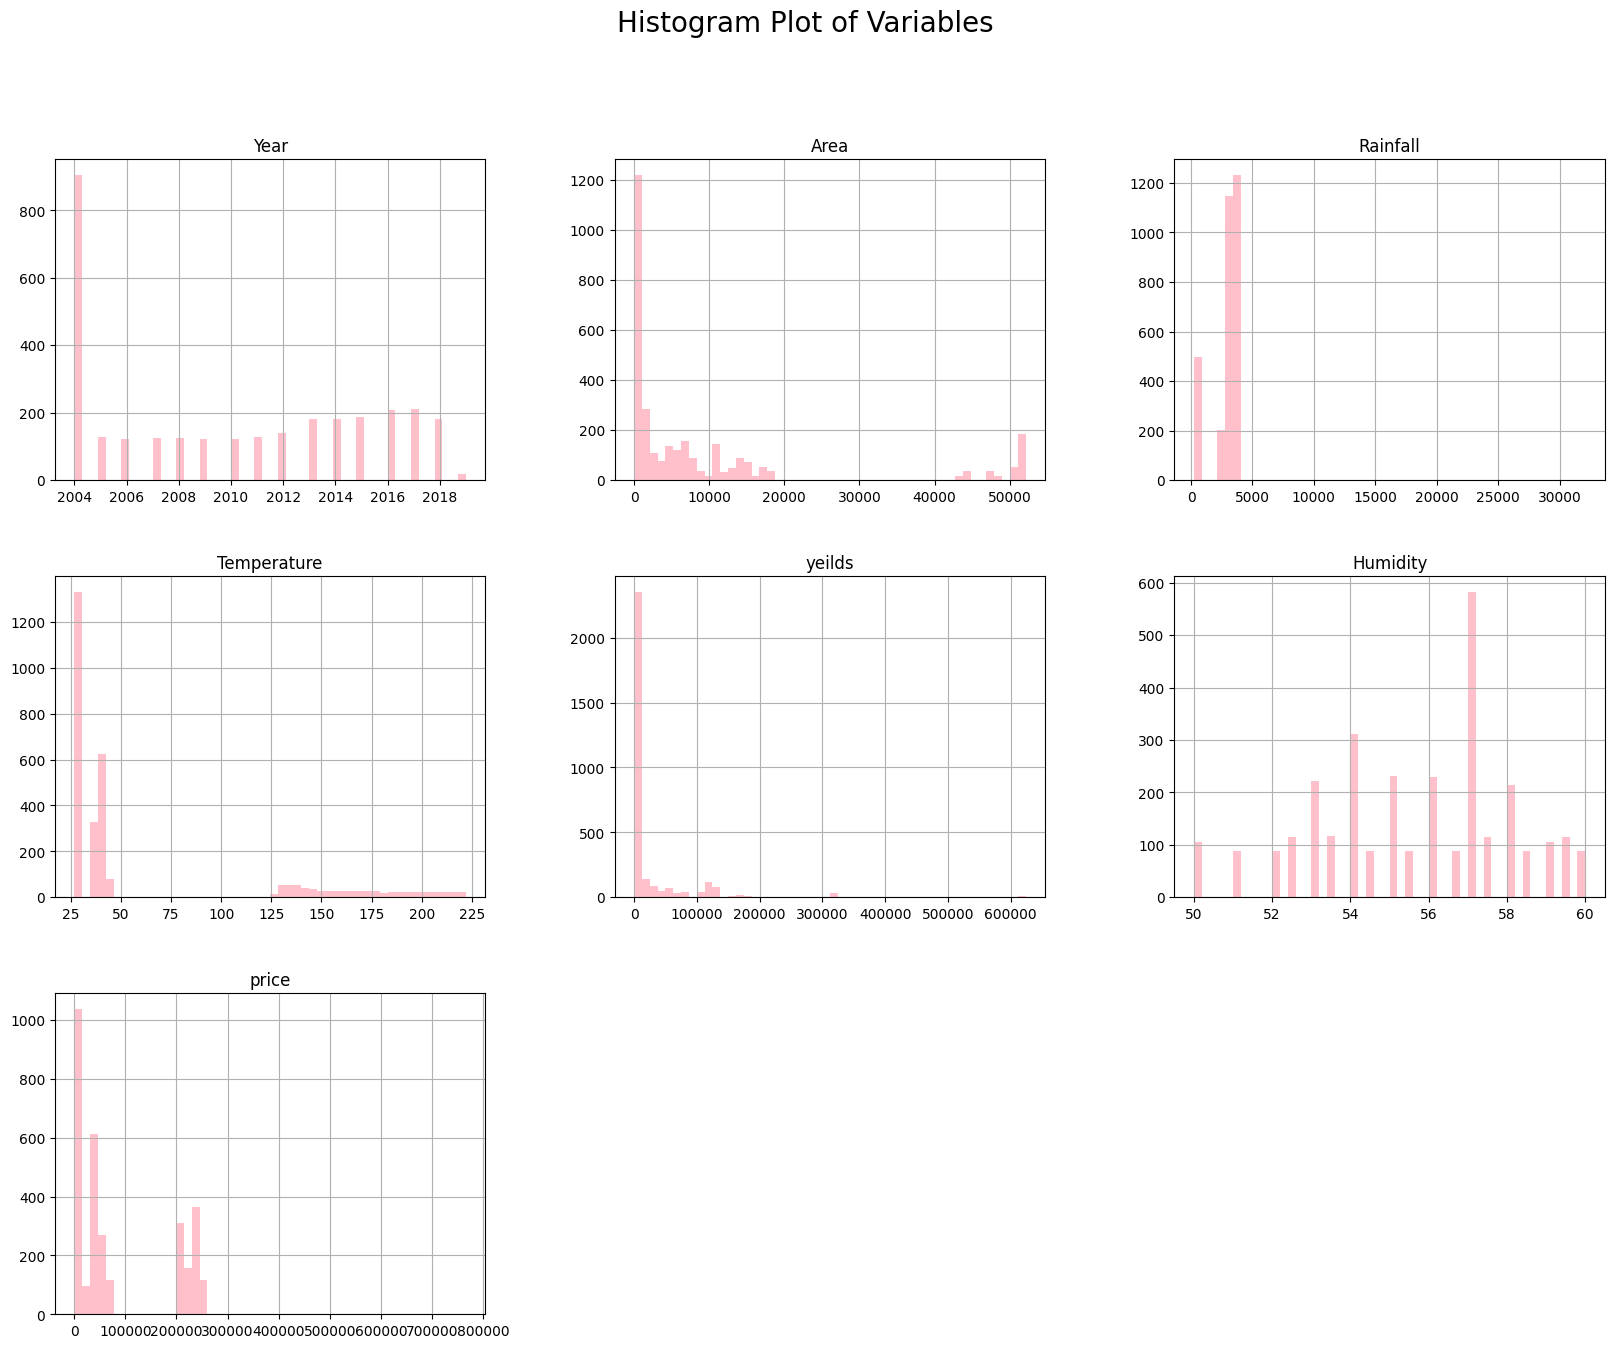

In [21]:
#Initial_Distribution_Check

df.hist(bins=50, figsize=(20,15), color = "pink")
plt.suptitle("Histogram Plot of Variables", fontsize=20)
plt.show()

#### Rainfall 


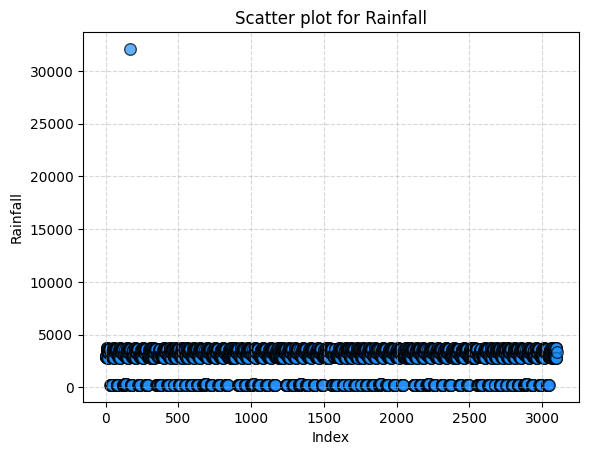

In [22]:
#Identify_Potential_Outliers

plt.scatter(df.index, df['Rainfall'], s=70, color='dodgerblue',edgecolors='black', alpha=0.7)
plt.title('Scatter plot for Rainfall')
plt.xlabel('Index')
plt.ylabel('Rainfall')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [23]:
df[df['Rainfall']>5000]

,Year,Location,Area,Rainfall,Temperature,Soil type,Irrigation,yeilds,Humidity,Crops,price,Season
165,2017,Gulbarga,66,32096.0,162.0,Black,Drip,5518.0,57.0,Cardamum,24848.0,Kharif


##### Remove Outliers

In [24]:
df['Rainfall'] = df['Rainfall'].replace(32096.0, np.nan)
df = df.dropna()
df = df.reset_index(drop=True)

##### Verify After Cleaning


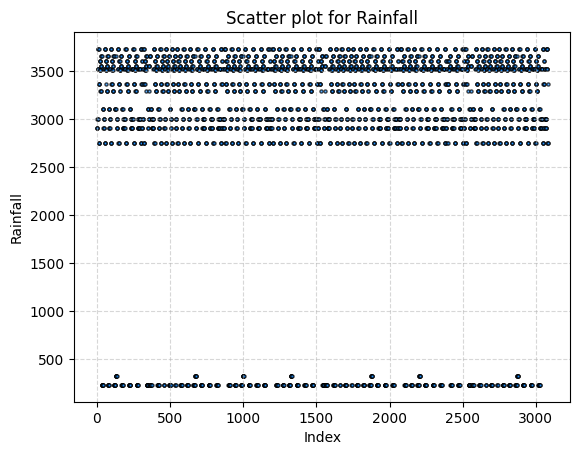

In [25]:
#Scatter_plot_Rainfall

plt.scatter(df.index, df['Rainfall'], s=5, color='dodgerblue',edgecolors='black', alpha=0.7)
plt.title('Scatter plot for Rainfall')
plt.xlabel('Index')
plt.ylabel('Rainfall')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

According to the data available on the internet on the volume of rainfall, this gap does not represent a specific case.

#### Humidity

In [26]:
#Check_for_Potential_Outliers

Humidity_min = int(df['Humidity'].min())
Humidity_max = int(df['Humidity'].max())

print(f"The observed humidity values range from {Humidity_min} to {Humidity_max}.")

The observed humidity values range from 50 to 60.


#### Crops

In [27]:
df['Crops'].value_counts()

Crops
Coconut      1440
Ginger        278
Coffee        150
Arecanut      150
Tea           150
Cardamum      149
Pepper        146
Paddy         146
Blackgram     135
Groundnut     131
Cashew        127
Cocoa          60
Cotton         21
Name: count, dtype: int64

#### Price

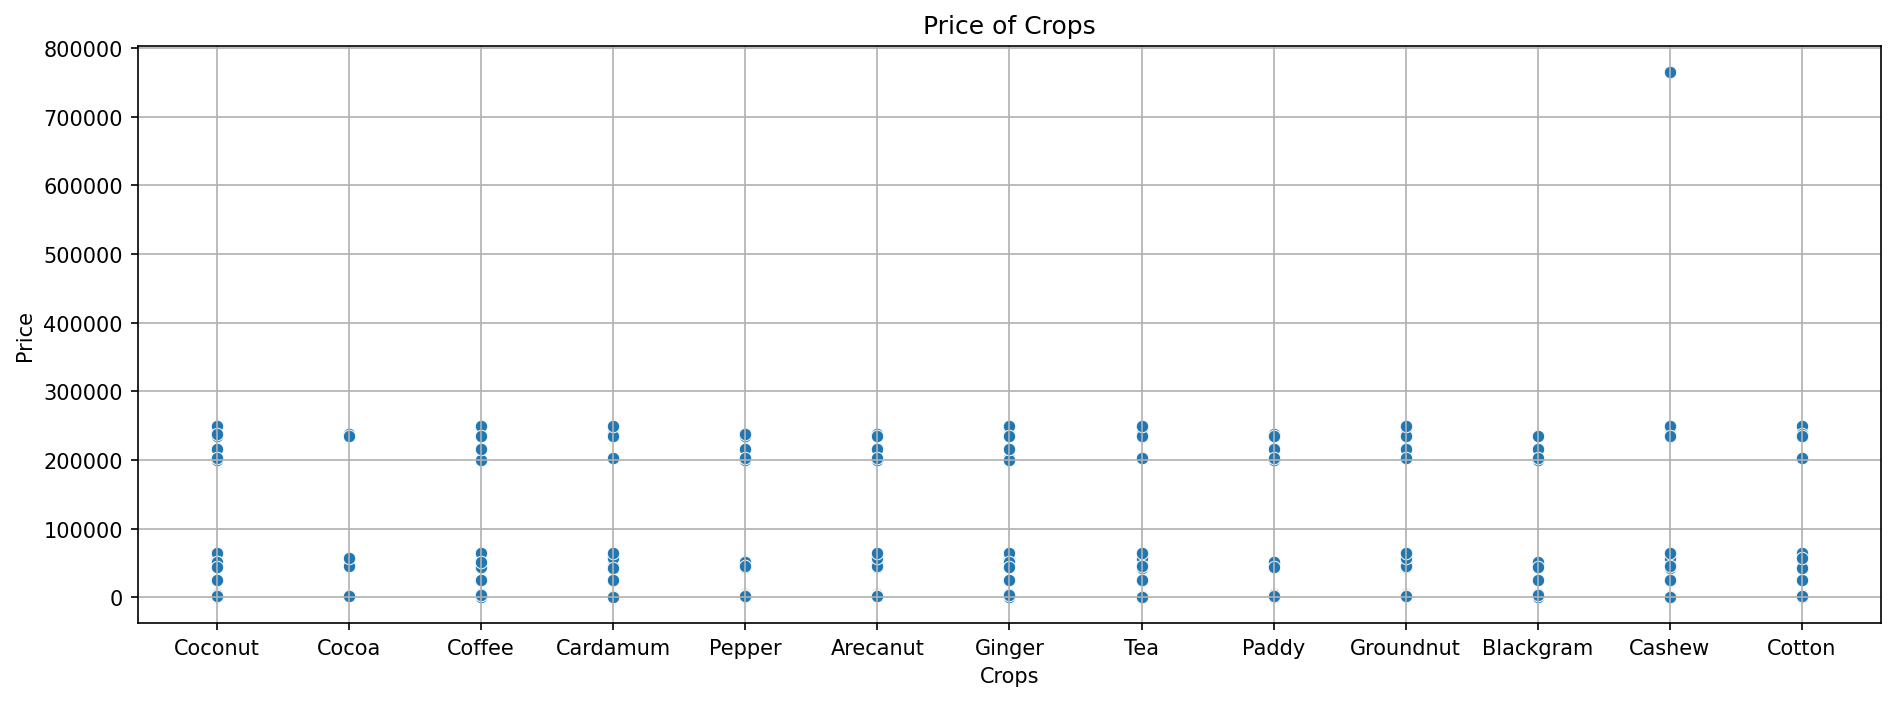

In [28]:
#Identify_Potential_Outliers

plt.figure(figsize = (15,5),dpi=150)
sns.scatterplot(x='Crops', y='price',data=df)

plt.title('Price of Crops')
plt.xlabel('Crops')
plt.ylabel('Price')
plt.grid(True)
plt.show()

In [29]:
df[df['price']>300000]

,Year,Location,Area,Rainfall,Temperature,Soil type,Irrigation,yeilds,Humidity,Crops,price,Season
2495,2014,Mangalore,7028,3522.8,38.0,Laterite,Drip,3472.0,59.0,Cashew,765551.0,Rabi


In [30]:
#Remove_Outlier

df['price'] = df['price'].replace(765551, np.nan)
df = df.dropna()
df = df.reset_index(drop=True)

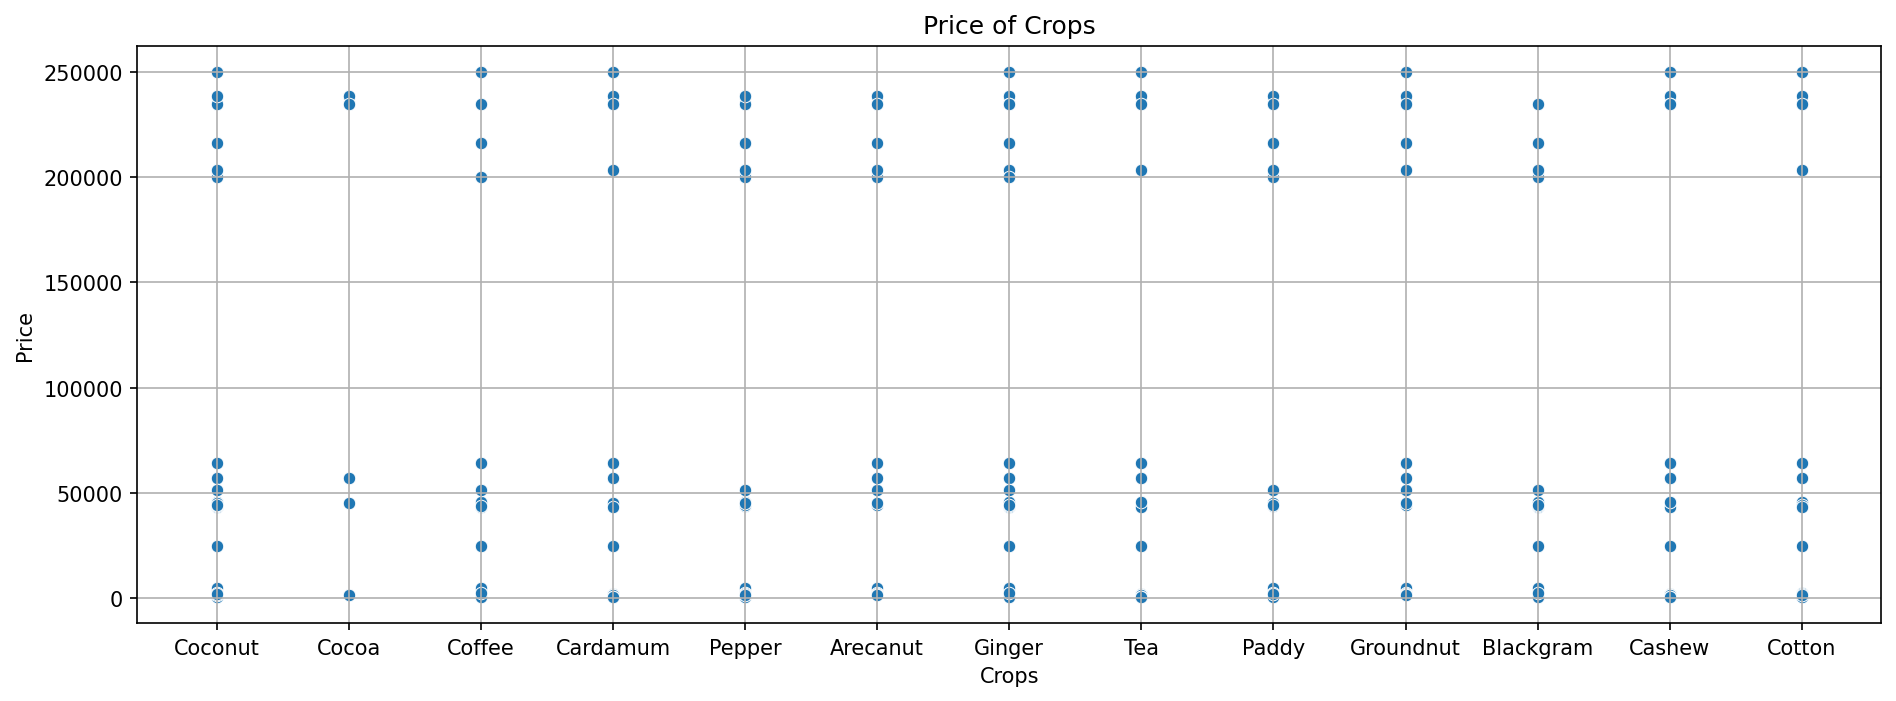

In [31]:
#Verify_After_Cleaning

plt.figure(figsize = (15,5),dpi=150)
sns.scatterplot(x='Crops', y='price',data=df)

plt.title('Price of Crops')
plt.xlabel('Crops')
plt.ylabel('Price')
plt.grid(True)
plt.show()

#### Temperature

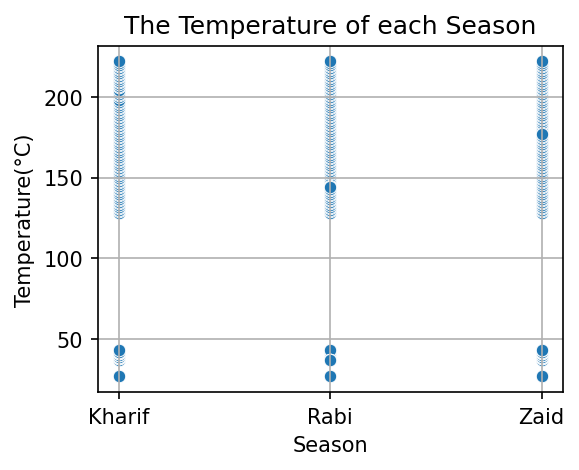

In [32]:
#Identify_Temperature_Data_Error

plt.figure(figsize = (4,3),dpi=150)
sns.scatterplot(x='Season', y='Temperature',data=df)

plt.title('The Temperature of each Season')
plt.xlabel('Season')
plt.ylabel('Temperature(°C)')
plt.grid(True)
plt.show()

In [33]:
#Correct_Temperature_Values

df.loc[df['Temperature'] > 100, 'Temperature'] = df.loc[df['Temperature'] > 100,'Temperature']/5

We have two temperature ranges with a very large gap and this indicates a scale error in the data entry. Since the data set information states that the values are entered in degrees Celsius, we divide the numbers above 100 by 5 so that the resulting range is more consistent with the lower temperature data range and the range available on the internet for the temperature ranges of Karnataka regions.


Note: In the Temperature Scatter Plot by Season, I expected a different temperature range for each season, but this particular case has not been seen so far.

Now I will apply the previous successful changes to the temperature column in df.

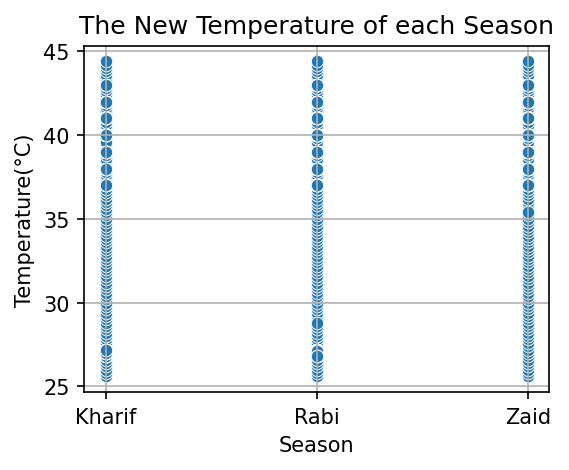

In [34]:
#Verify_Temperature_Values

plt.figure(figsize = (4,3),dpi=150)
sns.scatterplot(x='Season', y='Temperature',data=df)

plt.title('The New Temperature of each Season')
plt.xlabel('Season')
plt.ylabel('Temperature(°C)')
plt.grid(True)
plt.show()

## Exploratory Data Analysis

### Rainfall by Location

In [35]:
Rainfall_Location = df.groupby('Location')['Rainfall'].sum().reset_index()

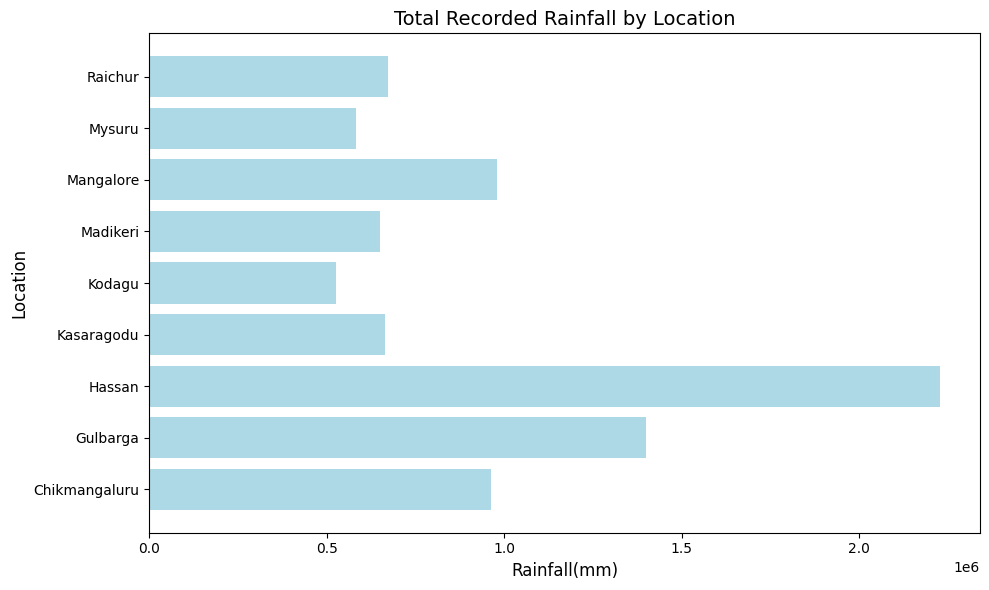

In [36]:
#BarPlot_for_Rainfall_in_each_Location

plt.figure(figsize=(10,6))
plt.barh(Rainfall_Location["Location"], Rainfall_Location["Rainfall"], color='lightblue')

plt.title('Total Recorded Rainfall by Location',fontsize=14)
plt.xlabel('Rainfall(mm)', fontsize=12)
plt.ylabel('Location', fontsize=12)

plt.tight_layout()
plt.show()

As observed in the related scatter plot above, we can see two different ranges of rainfall values with a large gap between them. However, this difference appears to be reasonable given the regional variation in rainfall across northern and southern Karnataka, potentially due to geographical factors such as proximity to the coast.

##### Key Insight

The total recorded rainfall varies considerably across locations. Hassan has the highest total recorded rainfall in the dataset, while Kodagu and Mysuru have relatively lower totals. These differences may reflect regional variation in the recorded rainfall data.

### Temperature by Location

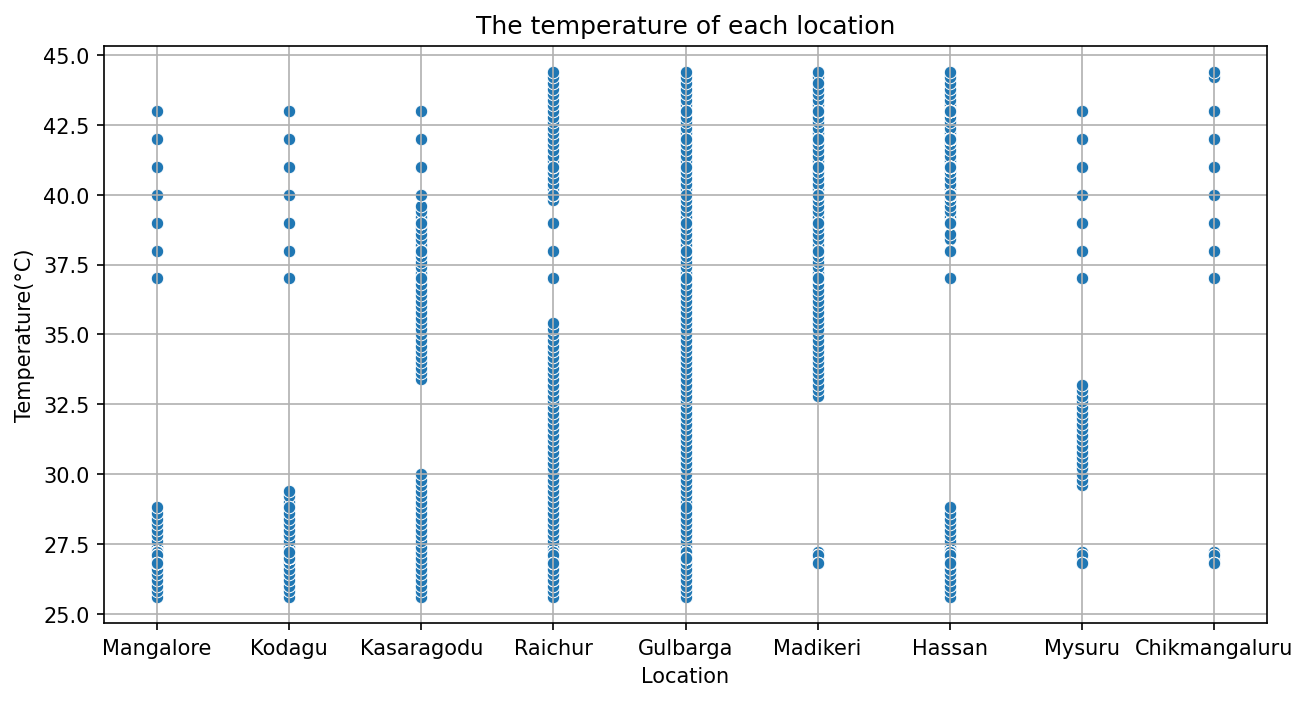

In [37]:
#Temp_by_loc

plt.figure(figsize = (10,5),dpi=150)
sns.scatterplot(x='Location', y='Temperature',data=df)

plt.title('The temperature of each location')
plt.xlabel('Location')
plt.ylabel('Temperature(°C)')
plt.grid(True)
plt.show()

##### Key Insight

Temperature values vary across locations, with several locations showing a relatively wide range of recorded temperatures. Although the distributions overlap considerably, some locations show greater variability than others.

### Distribution of Price

<Axes: xlabel='price', ylabel='Count'>

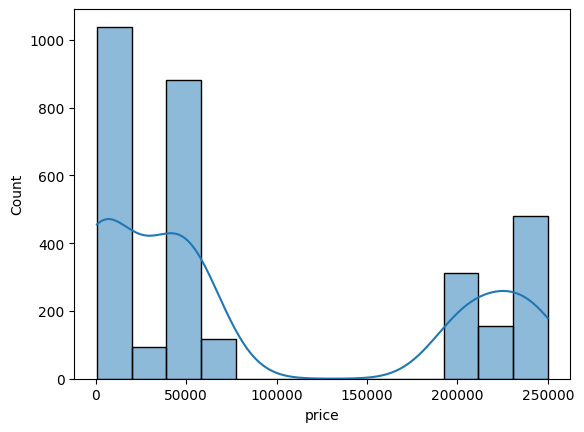

In [38]:
sns.histplot(df['price'], kde=True)

##### Key Insight

The price distribution is not uniform and shows two distinct ranges of values. Most observations are concentrated in the lower price range, while another substantial group is concentrated around 200,000 to 250,000.

### Crop Price comparison

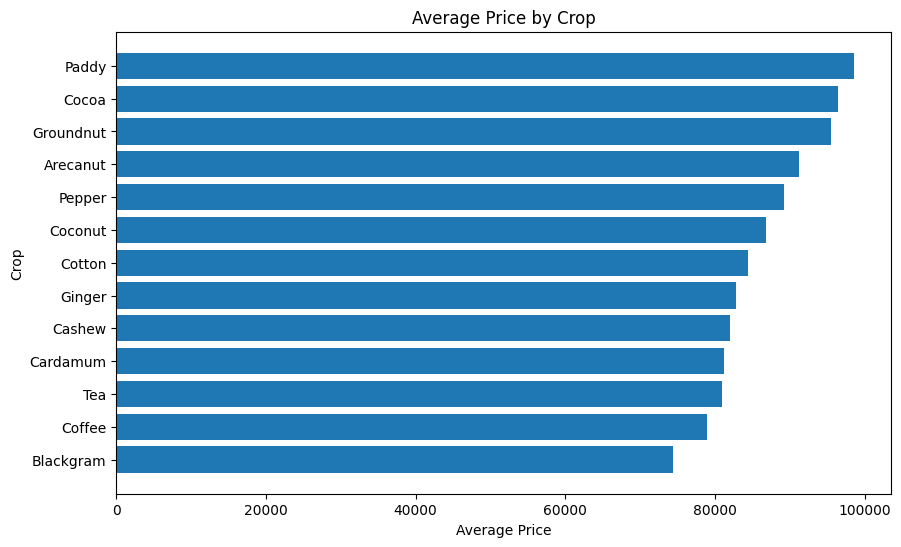

In [39]:
crop_price = df.groupby('Crops')['price'].mean().sort_values()

plt.figure(figsize=(10,6))
plt.barh(crop_price.index, crop_price.values)
plt.title('Average Price by Crop')
plt.xlabel('Average Price')
plt.ylabel('Crop')
plt.show()

##### Key Insight

The average price varies considerably across crop types. Paddy has the highest average price in the dataset, followed by Cocoa and Groundnut, while Blackgram has the lowest average price among the crops analyzed.

### Heatmap

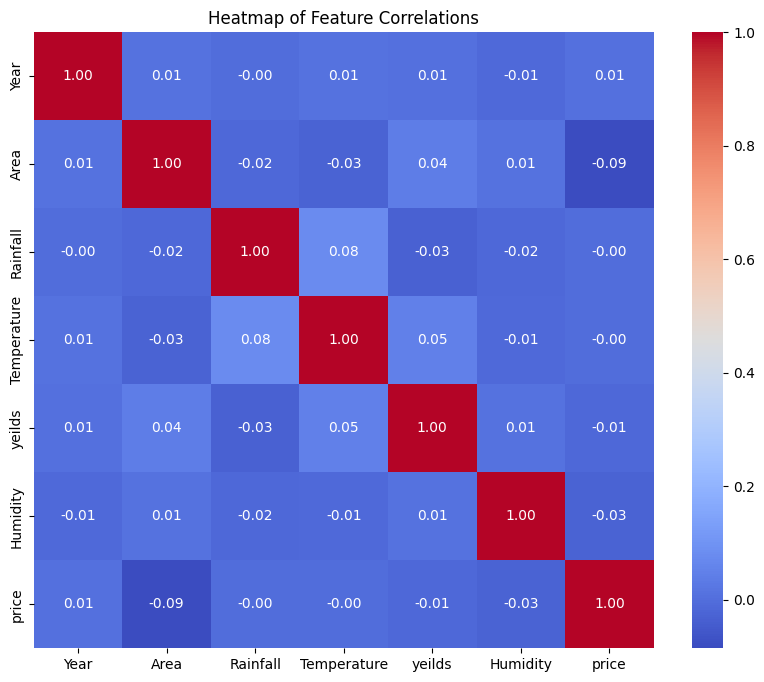

In [40]:
#Using_Heatmap_for_correlation

numeric_df = df.select_dtypes(include=['int', 'float'])

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap of Feature Correlations')
plt.show()

##### Key Insight

The correlation matrix shows that most numerical variables have very weak linear correlations with each other. The strongest observed correlations are still close to zero, suggesting that there are no strong linear relationships among the main numerical features in the overall dataset.

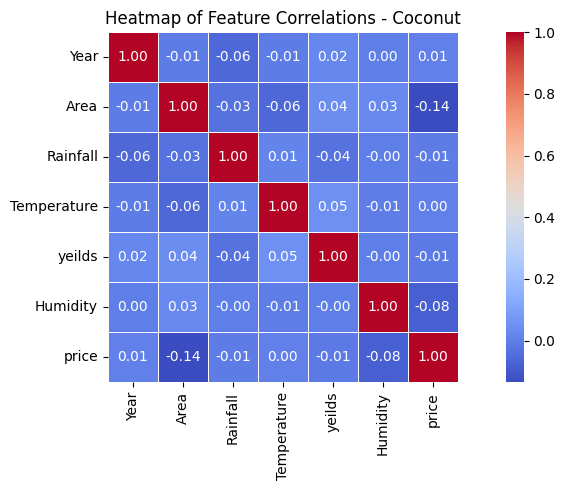

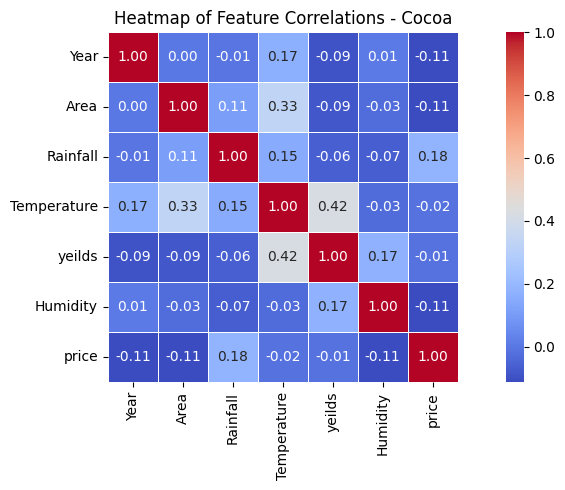

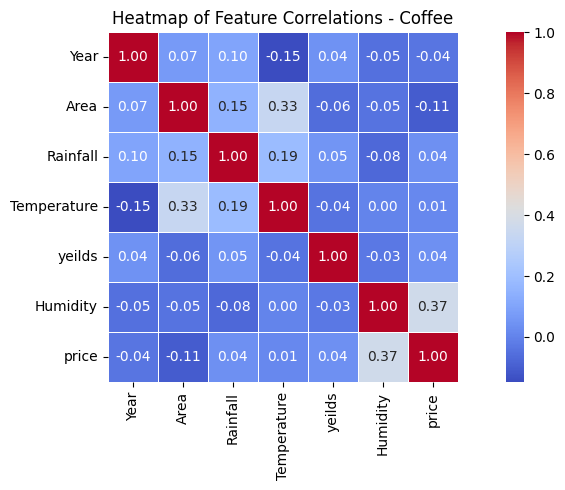

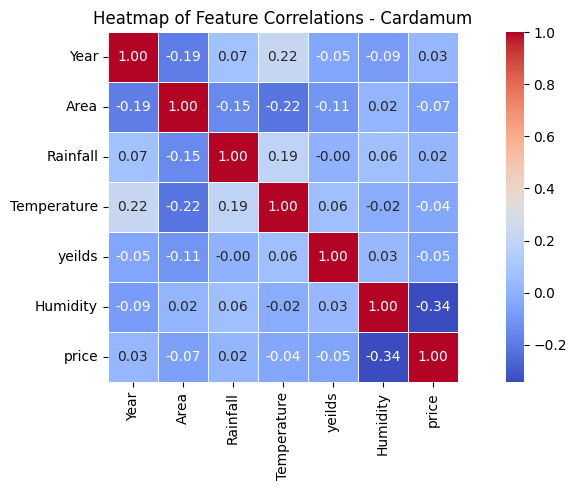

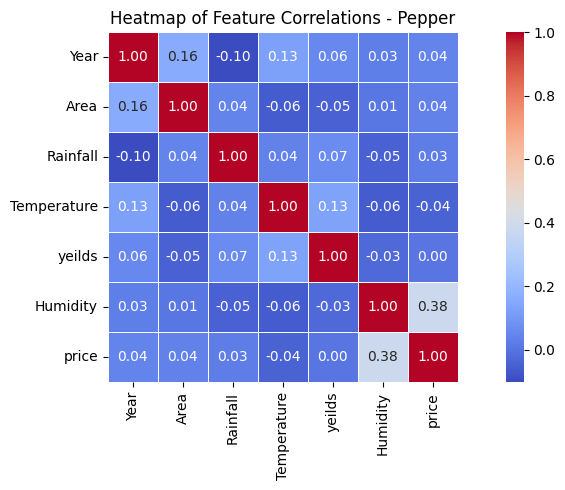

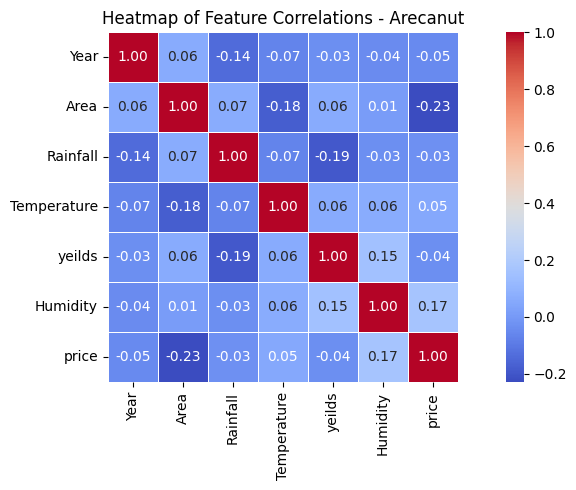

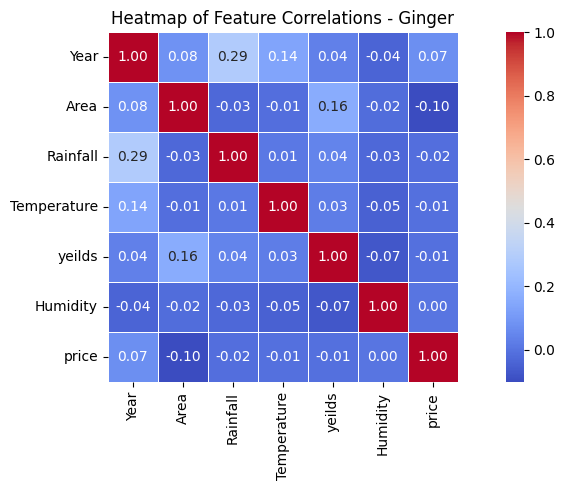

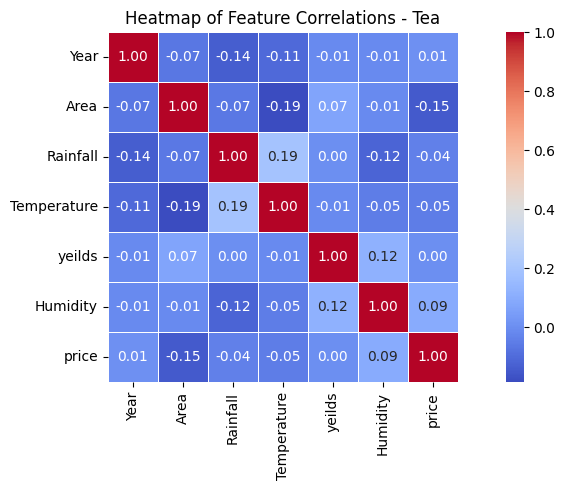

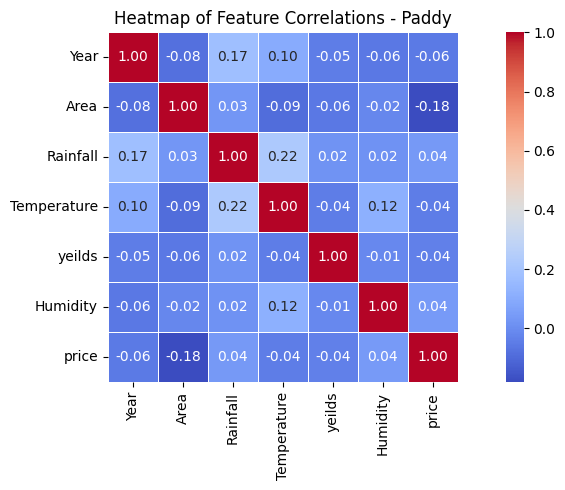

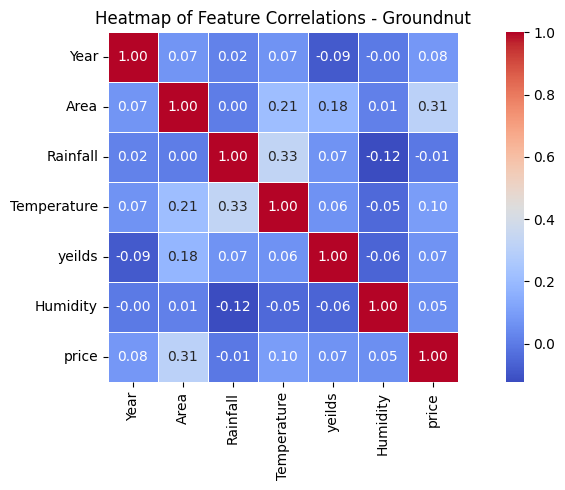

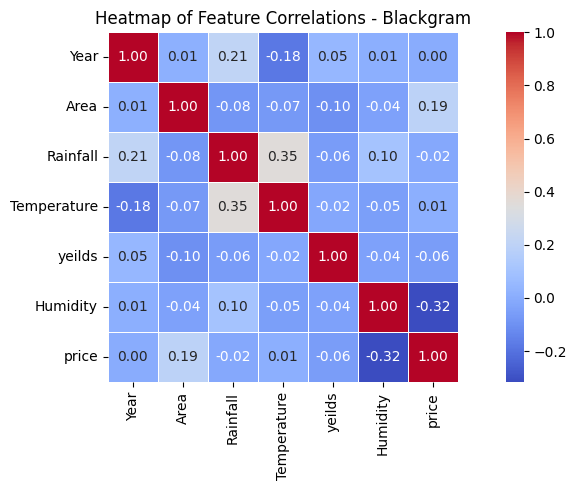

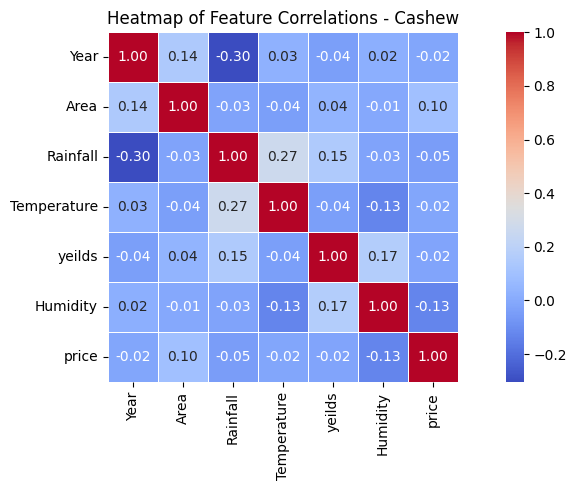

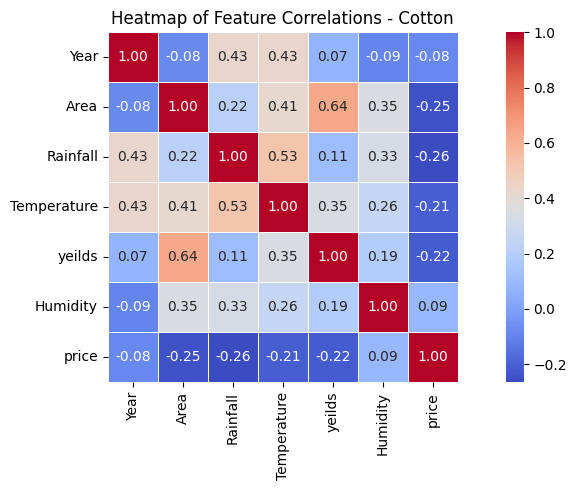

In [41]:
#Heatmap_for_each_Crop


products = df['Crops'].unique()

product_dfs = {}

for product in products:
    product_dfs[product] = df[df['Crops'] == product]

for crop_name, df_crop in product_dfs.items():

    numeric_df = df_crop.select_dtypes(include=['int64', 'float64'])
    
#Correlation_Matrix
    
    correlation_matrix = numeric_df.corr()
    
#HeatMap
    
    plt.figure(figsize=(10, 5))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True, linewidths=0.5)
    plt.title(f'Heatmap of Feature Correlations - {crop_name}')
    plt.tight_layout()
    plt.show()

##### Key Insight

While the overall dataset shows mostly weak correlations, the crop-specific heatmaps reveal some stronger relationships within individual crop groups. For example, Cotton shows a relatively strong positive correlation between Area and Yields, while Cocoa shows a positive relationship between Temperature and Yields. These relationships vary considerably across crop types.

### Rainfall vs Temperature

<Axes: xlabel='Rainfall', ylabel='Temperature'>

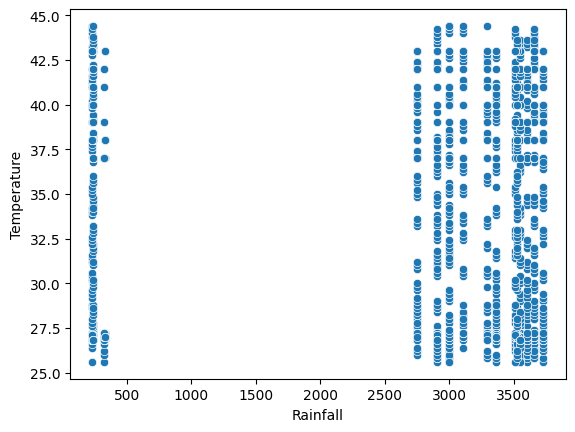

In [42]:
sns.scatterplot(data=df, x='Rainfall', y='Temperature')

##### Key Insight

The scatter plot shows two main ranges of rainfall values, while temperature varies across a broad range within both groups. No clear linear relationship between rainfall and temperature is visually apparent.

### Count of Crops Per Year

<Figure size 2000x800 with 0 Axes>

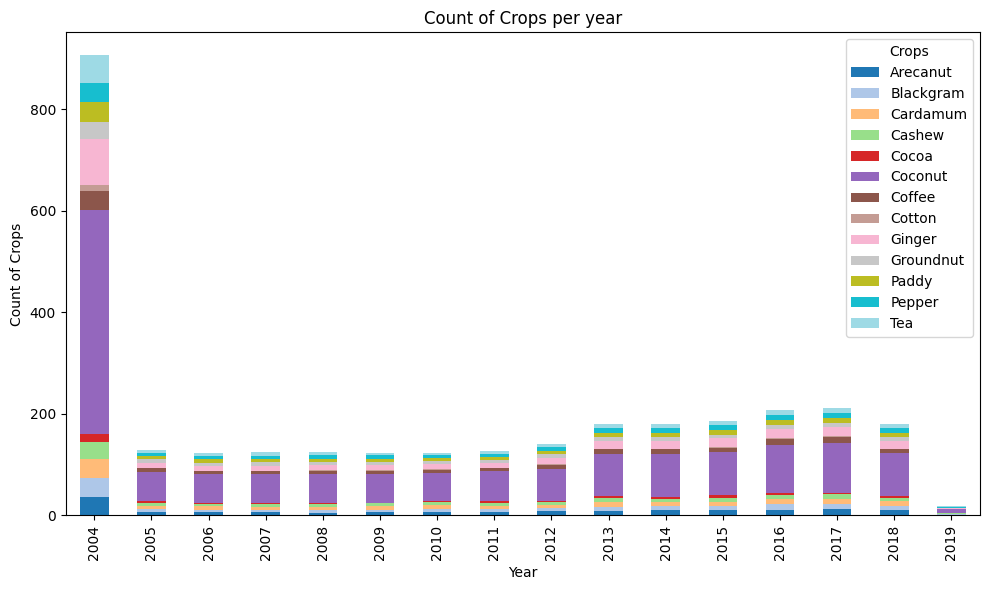

In [43]:
#Count_of_Crops_per_Year

pivot = df.pivot_table(index='Year', columns='Crops', aggfunc='size', fill_value=0)

#Stacked_bar

plt.figure(figsize=(10,4), dpi=200)
pivot.plot(kind='bar', stacked=True, figsize=(10, 6), colormap = "tab20")

plt.title("Count of Crops per year")
plt.xlabel("Year")
plt.ylabel("Count of Crops")
plt.legend(title= "Crops")
plt.tight_layout()
plt.show()

##### Key Insight

The number of recorded crop observations varies considerably across years. The dataset contains a particularly high number of records for 2004, while most other years have substantially fewer observations. The number of records also increases again between 2013 and 2017.

## Conclusion

This project provided an opportunity to systematically explore, clean, and analyze the dataset. Throughout the process, several data quality issues were identified and addressed, including missing values, inconsistent values, data type issues, and potential outliers.

The analysis also revealed several interesting patterns in rainfall, temperature, humidity, crop types, and crop prices across different regions and seasons.

Overall, this project strengthened my practical experience in data cleaning, exploratory data analysis, data visualization, and interpreting real-world datasets.